<a href="https://colab.research.google.com/github/SathishDissanayaka/statistical-analysis-neural-network-depth/blob/main/descriptive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descriptive Analysis: Does training deeper models increase representational capacity?

**Purpose:** Full descriptive statistics pass on the **preprocessed** dataset (`data_preprocessed.csv`)  
**Dataset:** 1800 MLP runs on Fashion-MNIST across depths, param budgets, corruption rates, and seeds  
**Key Points:** Engineered features available: `gen_gap`, `log_n_params`, `total_flops`, `epoch_fraction`, `loss_drop_10_to_final`, `depth_per_param`  
**Goal:** Confirm dataset suitability, surface patterns, and generate reportable statistics before inferential testing

---
## Sections
1. Setup & data load
2. Dataset integrity checks
3. Univariate distributions
4. Cell-level variance check
5. Depth vs accuracy — core question
6. Corruption as a capacity probe
7. Regime A vs Regime B comparison
8. Loss trajectory analysis
9. Engineered features — new diagnostics
10. Optimization failure audit
11. Summary table for reporting

---
## 1. Setup & data load

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Simple display helper for non-notebook runs
def display(obj):
    if hasattr(obj, 'to_string'):
        print(obj.to_string())
    else:
        print(obj)

# ── Plot defaults ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

# ── Load dataset (LOCAL FILE) ────────────────────────────────
DATA_PATH = '/content/data_preprocessed.csv'
df = pd.read_csv(DATA_PATH)

print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')
print(list(df.columns))

# Quick preview
df.head(5)

# Identify the NEW engineered columns vs original columns
original_cols = [
    'depth', 'width', 'n_params', 'seed', 'final_train_acc', 'final_test_acc',
    'final_train_loss', 'actual_epochs', 'flops_per_epoch', 'optimization_failure',
    'loss_ep10', 'loss_ep20', 'loss_ep30', 'loss_ep50', 'loss_ep70', 'loss_ep90',
    'regime', 'budget', 'fixed_w', 'corruption', 'param_err_pct'
]
new_cols = [c for c in df.columns if c not in original_cols]
print(f'Original columns ({len(original_cols)}): {original_cols}')
print(f'\nNew engineered columns ({len(new_cols)}): {new_cols}')

Loaded: 1800 rows x 30 columns
['depth', 'width', 'n_params', 'seed', 'final_train_acc', 'final_test_acc', 'final_train_loss', 'actual_epochs', 'flops_per_epoch', 'optimization_failure', 'loss_ep10', 'loss_ep20', 'loss_ep30', 'loss_ep50', 'loss_ep70', 'loss_ep90', 'regime', 'budget', 'fixed_w', 'corruption', 'param_err_pct', 'gen_gap', 'epoch_fraction', 'total_flops', 'loss_drop_10_to_final', 'depth_group', 'corruption_group', 'log_n_params', 'log_total_flops', 'depth_per_param']
Original columns (21): ['depth', 'width', 'n_params', 'seed', 'final_train_acc', 'final_test_acc', 'final_train_loss', 'actual_epochs', 'flops_per_epoch', 'optimization_failure', 'loss_ep10', 'loss_ep20', 'loss_ep30', 'loss_ep50', 'loss_ep70', 'loss_ep90', 'regime', 'budget', 'fixed_w', 'corruption', 'param_err_pct']

New engineered columns (9): ['gen_gap', 'epoch_fraction', 'total_flops', 'loss_drop_10_to_final', 'depth_group', 'corruption_group', 'log_n_params', 'log_total_flops', 'depth_per_param']


---
## 2. Dataset integrity checks
Before any analysis, verify the dataset is complete, balanced, and structurally sound.

In [ ]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_nonzero = missing[missing > 0]
if len(missing_nonzero) == 0:
    print('No missing values in any column.')
else:
    print(missing_nonzero.to_string())

print()
print('=== EXPECTED NaNs (by design) ===')
print('  budget        : NaN for fixed_width regime (no budget concept) -> expected')
print('  fixed_w       : NaN for iso_param regime (no fixed width) -> expected')
print('  param_err_pct : NaN for fixed_width regime -> expected')
print('  loss_ep10/20/30/50/70/90 : fully observed in this checkpoint')

print('=== UNIQUE VALUES PER CATEGORICAL / DISCRETE COLUMN ===')
for col in ['depth', 'regime', 'seed', 'corruption', 'budget', 'fixed_w', 'depth_group', 'corruption_group']:
    vals = sorted(df[col].dropna().unique())
    print(f'  {col:18s}: {vals}')

print()
print('=== RUN COUNTS ===')
print(f'  Total rows                : {len(df)}')
print(f'  optimization_failure=True : {df["optimization_failure"].sum()}')
print(f'  optimization_failure=False: {(~df["optimization_failure"].astype(bool)).sum()}')
print()
print('=== RUNS BY REGIME ===')
print(df['regime'].value_counts().to_string())

print('=== CELL COMPLETENESS CHECK ===')

# Regime A: budget x depth x corruption x seed
df_a = df[df['regime'] == 'iso_param']
expected_a = df_a.groupby(['budget', 'depth', 'corruption', 'seed']).size()
print(f'  Regime A (iso_param)  — duplicates: {(expected_a > 1).sum()}, missing cells: {(expected_a < 1).sum()}')

# Regime B: fixed_w x depth x corruption x seed
df_b = df[df['regime'] == 'fixed_width']
expected_b = df_b.groupby(['fixed_w', 'depth', 'corruption', 'seed']).size()
print(f'  Regime B (fixed_width)— duplicates: {(expected_b > 1).sum()}, missing cells: {(expected_b < 1).sum()}')

print()
print('=== RUNS PER DEPTH (perfectly balanced = 300 each) ===')
print(df.groupby('depth').size().rename('n_runs').to_string())

print('=== PARAMETER ERROR % (Regime A only) ===')
print(df_a['param_err_pct'].describe().round(3).to_string())
over2 = (df_a['param_err_pct'] > 2).sum()
print(f'\n  Runs with param_err_pct > 2%: {over2} (flagged for sensitivity check in regression)')

# Verify key engineered columns are internally consistent
print('=== ENGINEERED COLUMN CONSISTENCY CHECKS ===')

# gen_gap should equal final_train_acc - final_test_acc
computed_gap = df['final_train_acc'] - df['final_test_acc']
gap_diff = (df['gen_gap'] - computed_gap).abs().max()
print(f'  gen_gap vs (train_acc - test_acc) max diff : {gap_diff:.6f} {"[OK]" if gap_diff < 1e-6 else "[MISMATCH - check preprocessing]"}')

# log_n_params should equal log10(n_params)
computed_log = np.log10(df['n_params'])
log_diff = (df['log_n_params'] - computed_log).abs().max()
print(f'  log_n_params vs log10(n_params) max diff   : {log_diff:.6f} {"[OK]" if log_diff < 1e-6 else "[MISMATCH]"}')

# epoch_fraction should equal actual_epochs / 100
computed_frac = df['actual_epochs'] / 100
frac_diff = (df['epoch_fraction'] - computed_frac).abs().max()
print(f'  epoch_fraction vs actual_epochs/100 max diff: {frac_diff:.6f} {"[OK]" if frac_diff < 1e-6 else "[MISMATCH]"}')

# depth_per_param
computed_dpp = df['depth'] / df['n_params']
dpp_diff = (df['depth_per_param'] - computed_dpp).abs().max()
print(f'  depth_per_param vs depth/n_params max diff  : {dpp_diff:.8f} {"[OK]" if dpp_diff < 1e-10 else "[MISMATCH]"}')

=== MISSING VALUES ===
budget           900
fixed_w          900
param_err_pct    900

=== EXPECTED NaNs (by design) ===
  budget        : NaN for fixed_width regime (no budget concept) -> expected
  fixed_w       : NaN for iso_param regime (no fixed width) -> expected
  param_err_pct : NaN for fixed_width regime -> expected
  loss_ep10/20/30/50/70/90 : fully observed in this checkpoint
=== UNIQUE VALUES PER CATEGORICAL / DISCRETE COLUMN ===
  depth             : [np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(12), np.int64(16)]
  regime            : ['fixed_width', 'iso_param']
  seed              : [np.int64(7), np.int64(13), np.int64(17), np.int64(37), np.int64(42), np.int64(77), np.int64(99), np.int64(123), np.int64(200), np.int64(256)]
  corruption        : [np.float64(0.0), np.float64(0.6), np.float64(1.0)]
  budget            : [np.float64(20000.0), np.float64(25000.0), np.float64(30000.0), np.float64(35000.0), np.float64(40000.0)]
  fixed_w           : [np.float64

---
## 3. Univariate distributions
Summary statistics and histograms for all key numeric columns — including new engineered features.

=== EXTENDED DESCRIPTIVE STATISTICS (including engineered features) ===
                        count          mean           std           min           25%           50%           75%           max   skew  kurtosis
final_train_acc        1800.0  7.455000e-01  2.056000e-01  3.553000e-01  5.639000e-01  7.331000e-01  9.868000e-01  1.000000e+00 -0.060    -1.413
final_test_acc         1800.0  4.435000e-01  3.321000e-01  1.300000e-02  2.380000e-02  4.890000e-01  8.212000e-01  8.433000e-01 -0.166    -1.537
final_train_loss       1800.0  7.948000e-01  6.108000e-01  2.500000e-03  6.030000e-02  8.694000e-01  1.348600e+00  1.814100e+00 -0.080    -1.508
actual_epochs          1800.0  1.000000e+02  0.000000e+00  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02  0.000     0.000
n_params               1800.0  2.221010e+04  9.131628e+03  9.754000e+03  1.473700e+04  1.923050e+04  2.933100e+04  3.985900e+04  0.560    -0.927
param_err_pct           900.0  1.870700e+00  1.577600e+00 

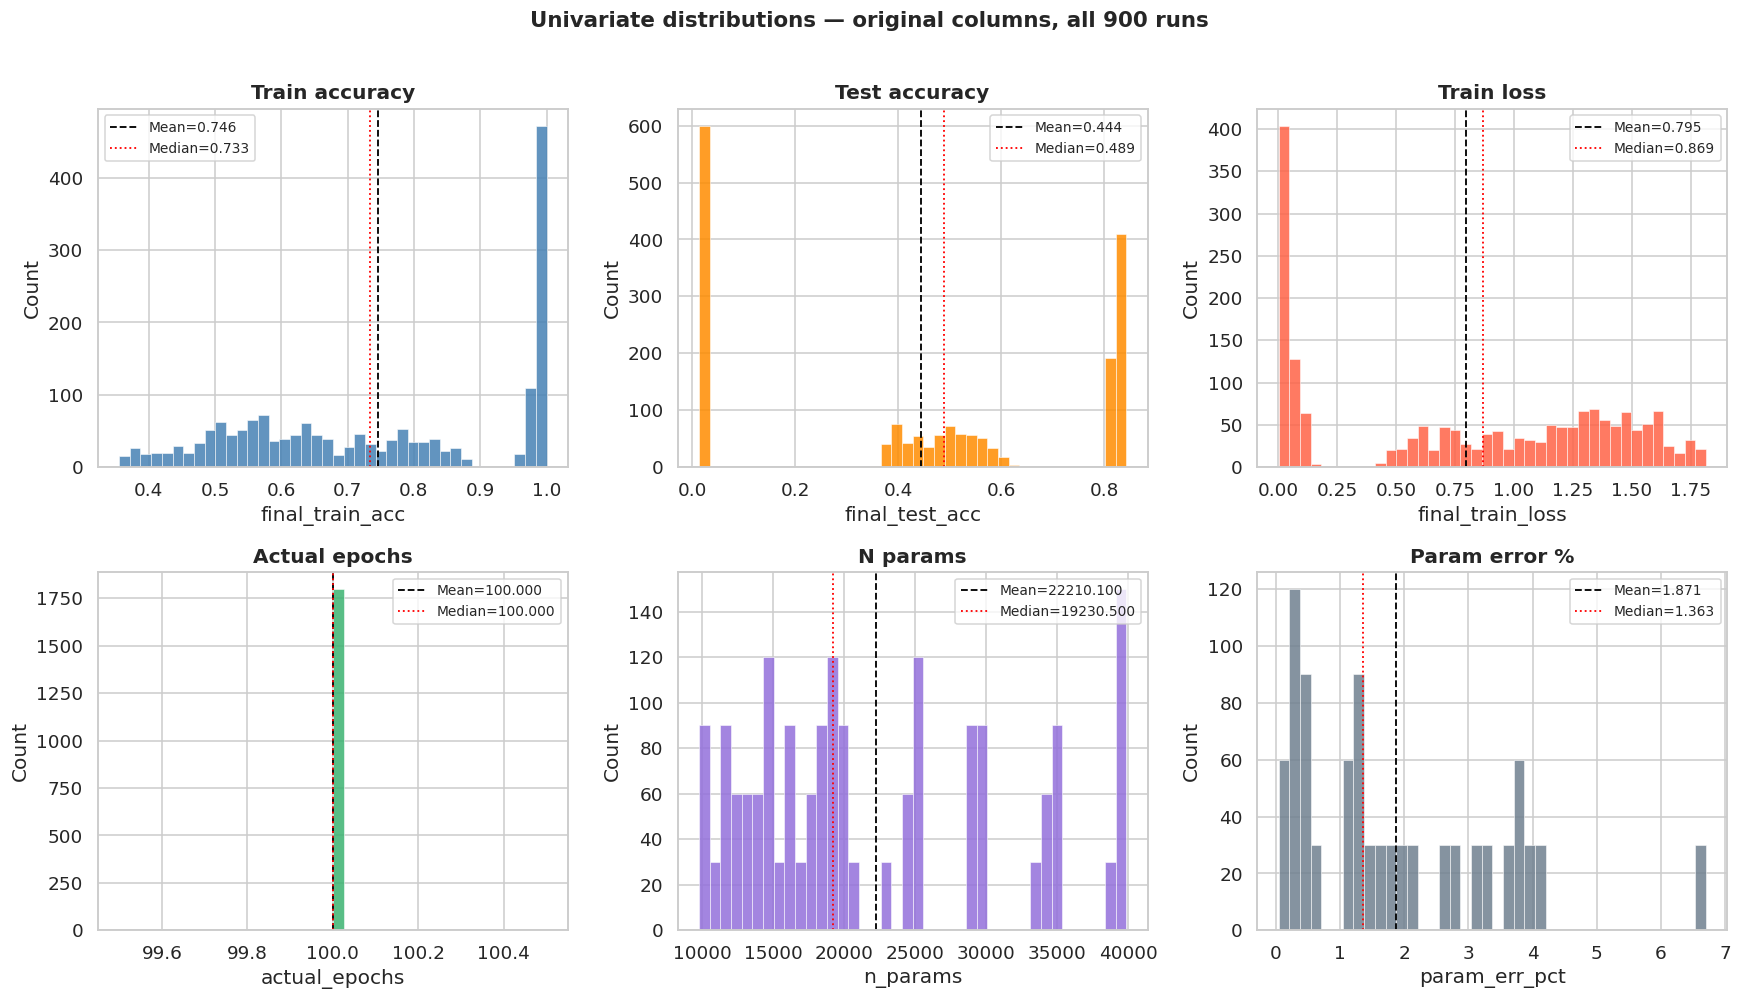

Saved: univariate_original.png


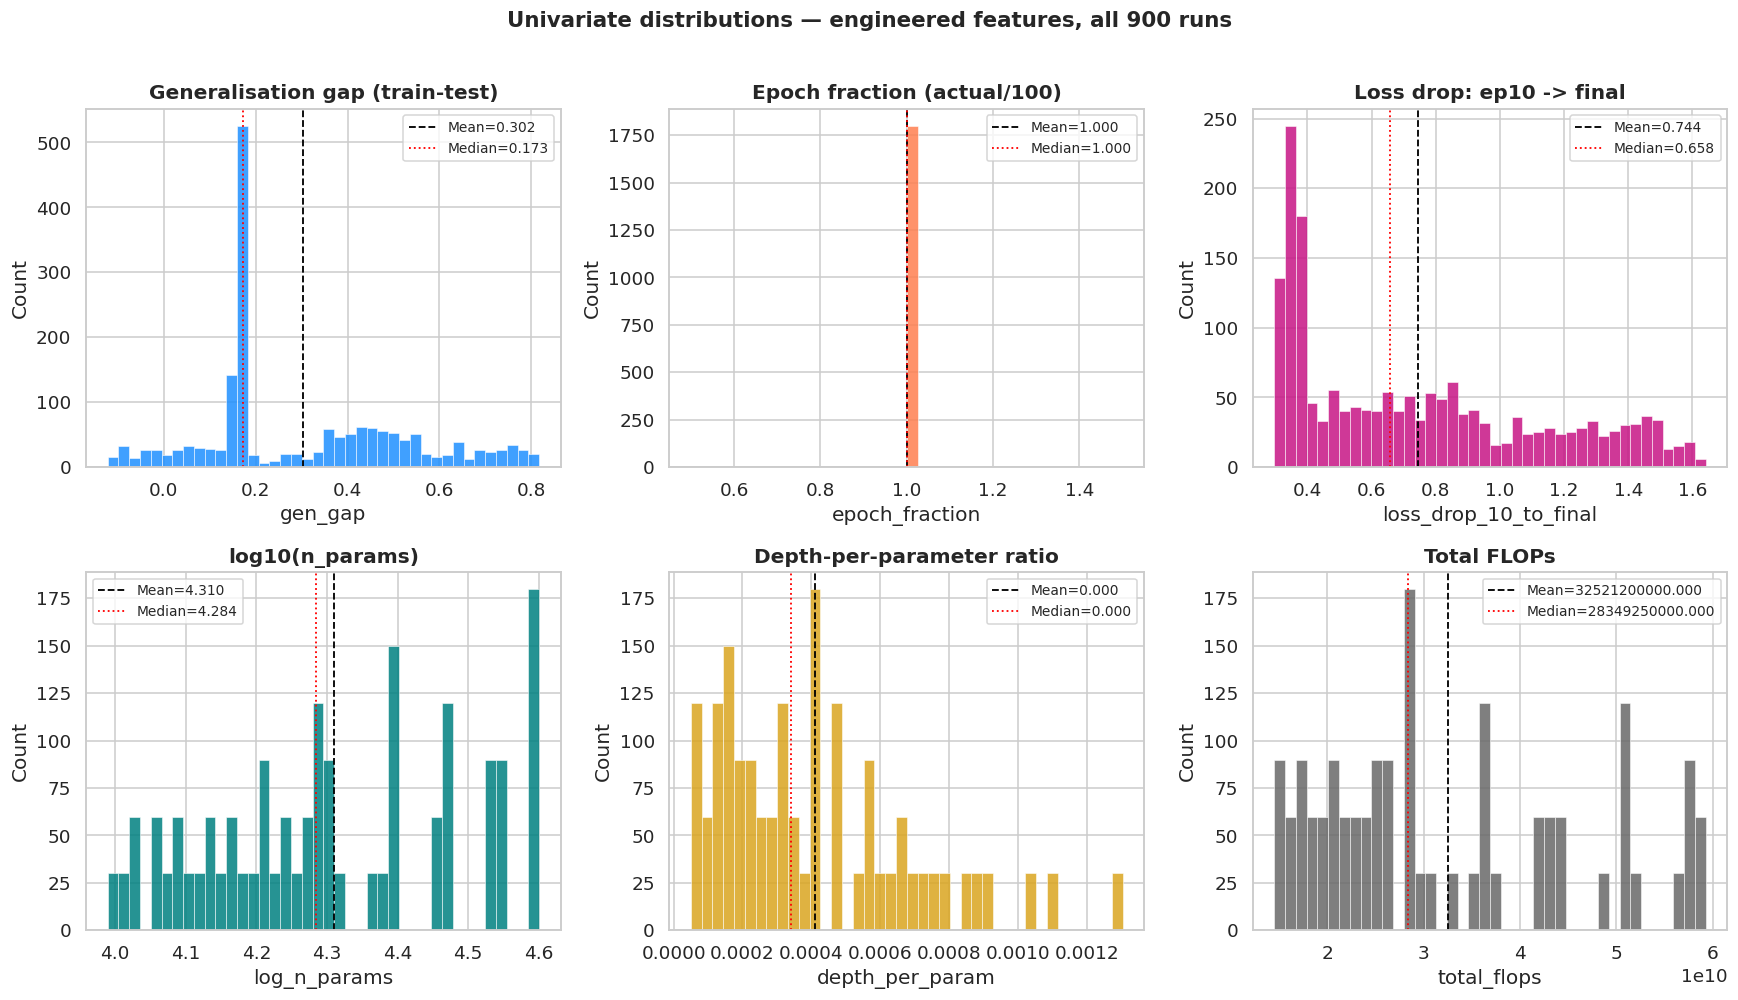

Saved: univariate_engineered.png


In [ ]:
# Extended describe including new engineered columns
numeric_cols = [
    'final_train_acc', 'final_test_acc', 'final_train_loss',
    'actual_epochs', 'n_params', 'param_err_pct',
    'gen_gap', 'epoch_fraction', 'total_flops',
    'loss_drop_10_to_final', 'log_n_params', 'depth_per_param'
]
desc = df[numeric_cols].describe().T.round(4)
desc['skew']     = df[numeric_cols].skew().round(3)
desc['kurtosis'] = df[numeric_cols].kurtosis().round(3)
print('=== EXTENDED DESCRIPTIVE STATISTICS (including engineered features) ===')
display(desc)

# Histograms — original outcome variables
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_configs = [
    ('final_train_acc',  'Train accuracy',   'steelblue'),
    ('final_test_acc',   'Test accuracy',    'darkorange'),
    ('final_train_loss', 'Train loss',       'tomato'),
    ('actual_epochs',   'Actual epochs',    'mediumseagreen'),
    ('n_params',        'N params',         'mediumpurple'),
    ('param_err_pct',   'Param error %',    'slategray'),
]

for ax, (col, label, color) in zip(axes, plot_configs):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.2, label=f'Mean={data.mean():.3f}')
    ax.axvline(data.median(), color='red',   linestyle=':',  linewidth=1.2, label=f'Median={data.median():.3f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

fig.suptitle('Univariate distributions — original columns, all 900 runs',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_original.png', dpi=130)
plt.show()
print('Saved: univariate_original.png')

# Histograms — new engineered features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

eng_plot_configs = [
    ('gen_gap',              'Generalisation gap (train-test)',  'dodgerblue'),
    ('epoch_fraction',       'Epoch fraction (actual/100)',      'coral'),
    ('loss_drop_10_to_final','Loss drop: ep10 -> final',         'mediumvioletred'),
    ('log_n_params',         'log10(n_params)',                  'teal'),
    ('depth_per_param',      'Depth-per-parameter ratio',       'goldenrod'),
    ('total_flops',          'Total FLOPs',                     'dimgray'),
]

for ax, (col, label, color) in zip(axes, eng_plot_configs):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.2, label=f'Mean={data.mean():.3f}')
    ax.axvline(data.median(), color='red',   linestyle=':',  linewidth=1.2, label=f'Median={data.median():.3f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

fig.suptitle('Univariate distributions — engineered features, all 900 runs',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_engineered.png', dpi=130)
plt.show()
print('Saved: univariate_engineered.png')

---
## 4. Cell-level variance check
Are 10 seeds per condition producing enough variance for inferential testing?  
Now using both `final_test_acc` and `gen_gap` (available as engineered column) as metrics.

=== WITHIN-CELL VARIANCE (grouped by regime x depth x corruption) ===
--- test accuracy ---
  Median std : 0.0042
  Mean std   : 0.0149
  Max std    : 0.0468
  Min std    : 0.0023
  Cells with std < 0.005: 21 (near ceiling/floor)
  Cells with std > 0.05 : 0 (optimiser sensitivity)

--- gen_gap (train-test gap) ---
  Median std : 0.0705
  Max std    : 0.1292


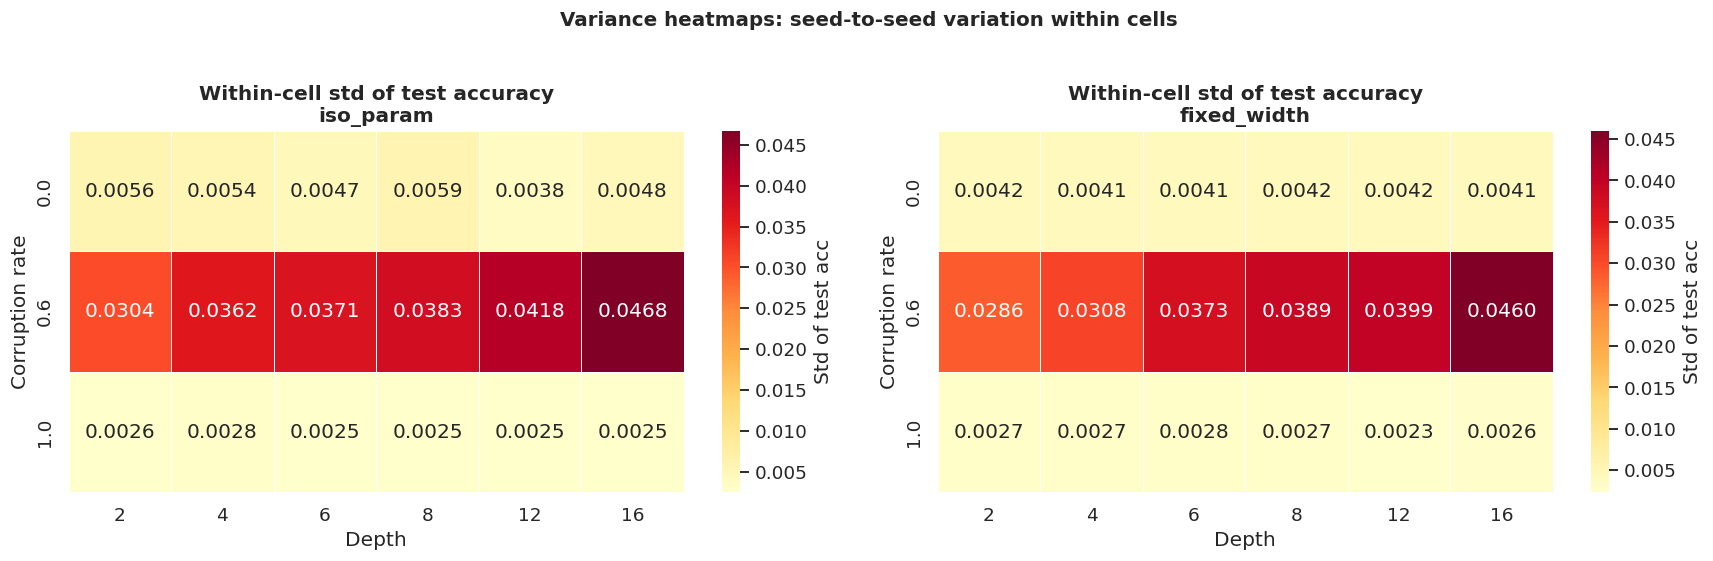

Saved: cell_variance_heatmaps.png


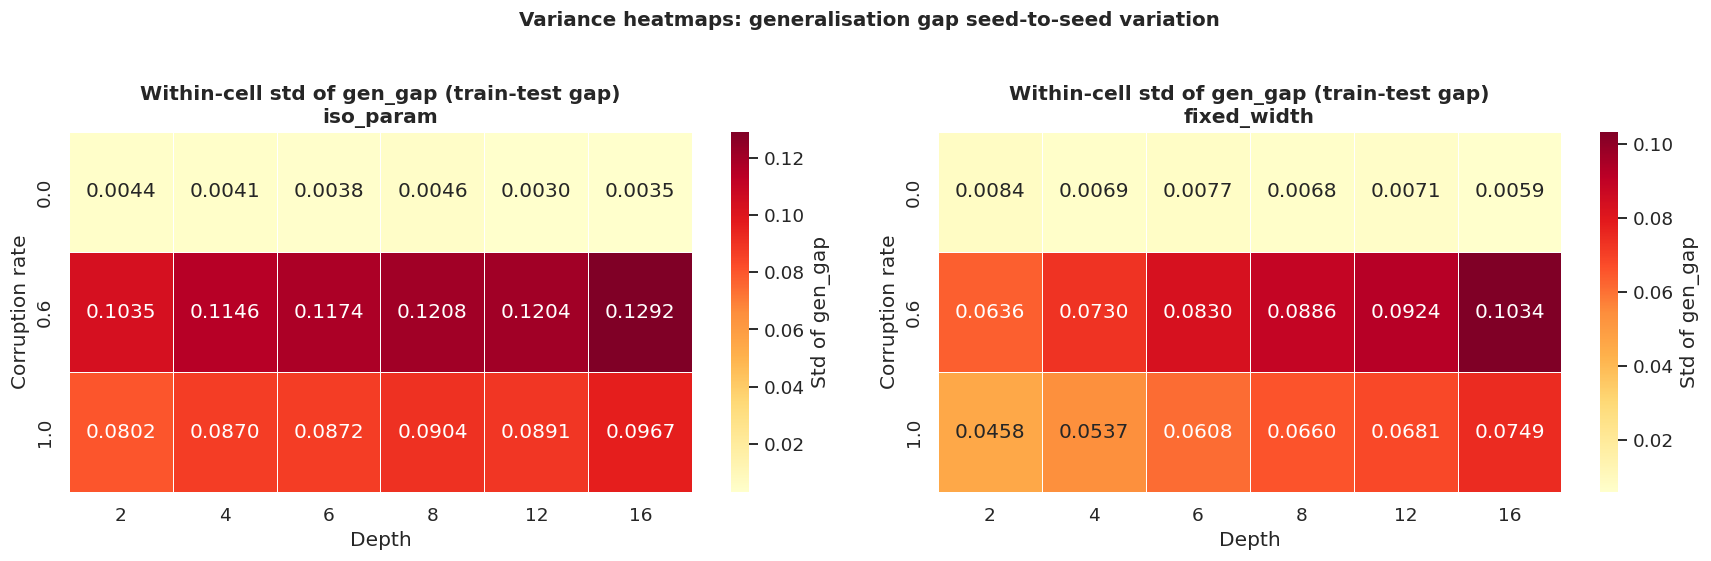

Saved: cell_variance_gen_gap_heatmaps.png


In [ ]:
# Compute within-cell std for test accuracy and gen_gap
cell_variance = (
    df
    .groupby(['regime', 'depth', 'corruption'])
    .agg(
        mean_test_acc  = ('final_test_acc', 'mean'),
        std_test_acc   = ('final_test_acc', 'std'),
        std_train_acc  = ('final_train_acc', 'std'),
        std_gen_gap    = ('gen_gap', 'std'),
        n_seeds        = ('seed', 'count')
    )
    .reset_index()
)

print('=== WITHIN-CELL VARIANCE (grouped by regime x depth x corruption) ===')
print('--- test accuracy ---')
print(f'  Median std : {cell_variance["std_test_acc"].median():.4f}')
print(f'  Mean std   : {cell_variance["std_test_acc"].mean():.4f}')
print(f'  Max std    : {cell_variance["std_test_acc"].max():.4f}')
print(f'  Min std    : {cell_variance["std_test_acc"].min():.4f}')
print(f'  Cells with std < 0.005: {(cell_variance["std_test_acc"] < 0.005).sum()} (near ceiling/floor)')
print(f'  Cells with std > 0.05 : {(cell_variance["std_test_acc"] > 0.05).sum()} (optimiser sensitivity)')
print()
print('--- gen_gap (train-test gap) ---')
print(f'  Median std : {cell_variance["std_gen_gap"].median():.4f}')
print(f'  Max std    : {cell_variance["std_gen_gap"].max():.4f}')

# Heatmaps: per-cell std of test accuracy for each regime
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, regime_name in zip(axes, ['iso_param', 'fixed_width']):
    sub = cell_variance[cell_variance['regime'] == regime_name]
    pivot = sub.pivot(index='corruption', columns='depth', values='std_test_acc')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Std of test acc'})
    ax.set_title(f'Within-cell std of test accuracy\n{regime_name}', fontweight='bold')
    ax.set_xlabel('Depth')
    ax.set_ylabel('Corruption rate')

plt.suptitle('Variance heatmaps: seed-to-seed variation within cells',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cell_variance_heatmaps.png', dpi=130)
plt.show()
print('Saved: cell_variance_heatmaps.png')

# Heatmap: per-cell std of gen_gap — new comparison using engineered column
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, regime_name in zip(axes, ['iso_param', 'fixed_width']):
    sub = cell_variance[cell_variance['regime'] == regime_name]
    pivot = sub.pivot(index='corruption', columns='depth', values='std_gen_gap')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Std of gen_gap'})
    ax.set_title(f'Within-cell std of gen_gap (train-test gap)\n{regime_name}', fontweight='bold')
    ax.set_xlabel('Depth')
    ax.set_ylabel('Corruption rate')

plt.suptitle('Variance heatmaps: generalisation gap seed-to-seed variation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cell_variance_gen_gap_heatmaps.png', dpi=130)
plt.show()
print('Saved: cell_variance_gen_gap_heatmaps.png')

---
## 5. Depth vs accuracy — the core question Train accuracy vs depth by corruption rate ⭐

=== ACCURACY + GEN_GAP + EPOCH_FRACTION BY DEPTH (all conditions pooled) ===
      final_train_acc                 final_test_acc                 gen_gap                 epoch_fraction            
                 mean     std  median           mean     std  median    mean     std  median           mean  std median
depth                                                                                                                  
2              0.7282  0.2143  0.7173         0.4410  0.3307  0.4845  0.2872  0.2188  0.1732            1.0  0.0    1.0
4              0.7445  0.2091  0.7456         0.4412  0.3321  0.4884  0.3033  0.2276  0.1732            1.0  0.0    1.0
6              0.7491  0.2064  0.7531         0.4427  0.3326  0.4878  0.3064  0.2293  0.1732            1.0  0.0    1.0
8              0.7516  0.2042  0.7453         0.4431  0.3330  0.4865  0.3085  0.2298  0.1723            1.0  0.0    1.0
12             0.7528  0.2000  0.7419         0.4449  0.3335  0.4905  0.3079  0.227

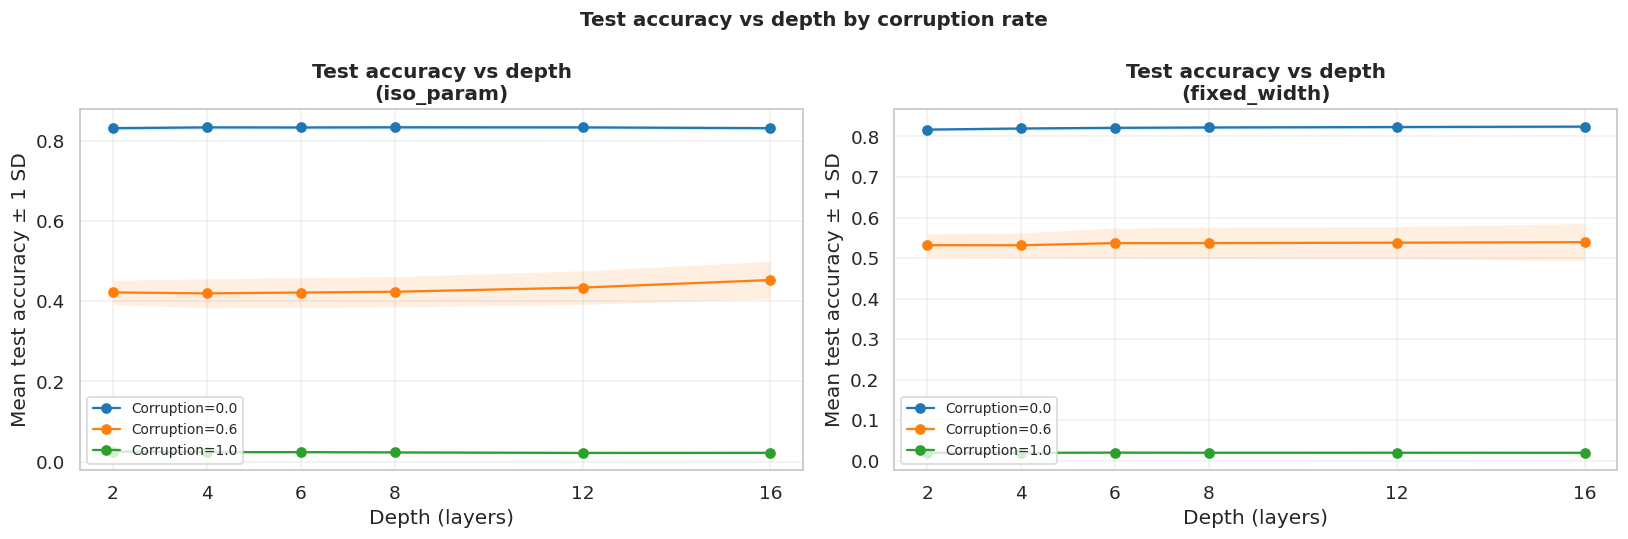

Saved: test_acc_vs_depth.png


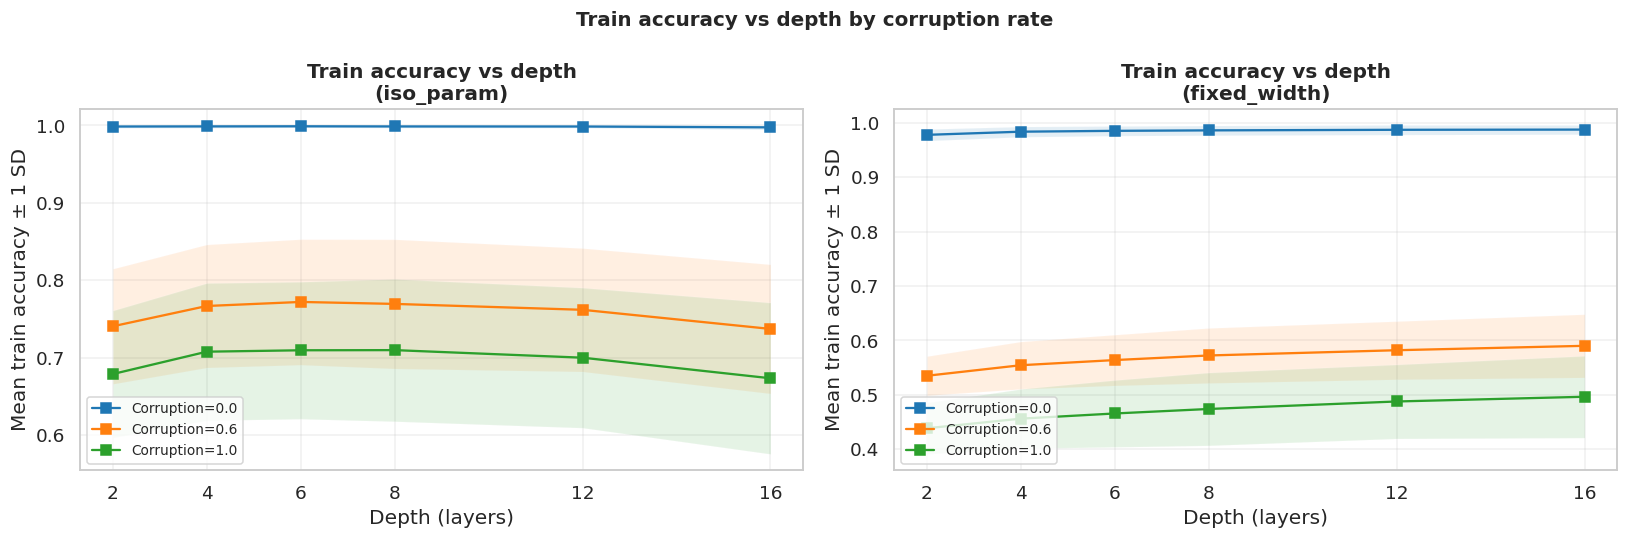

Saved: train_acc_vs_depth.png


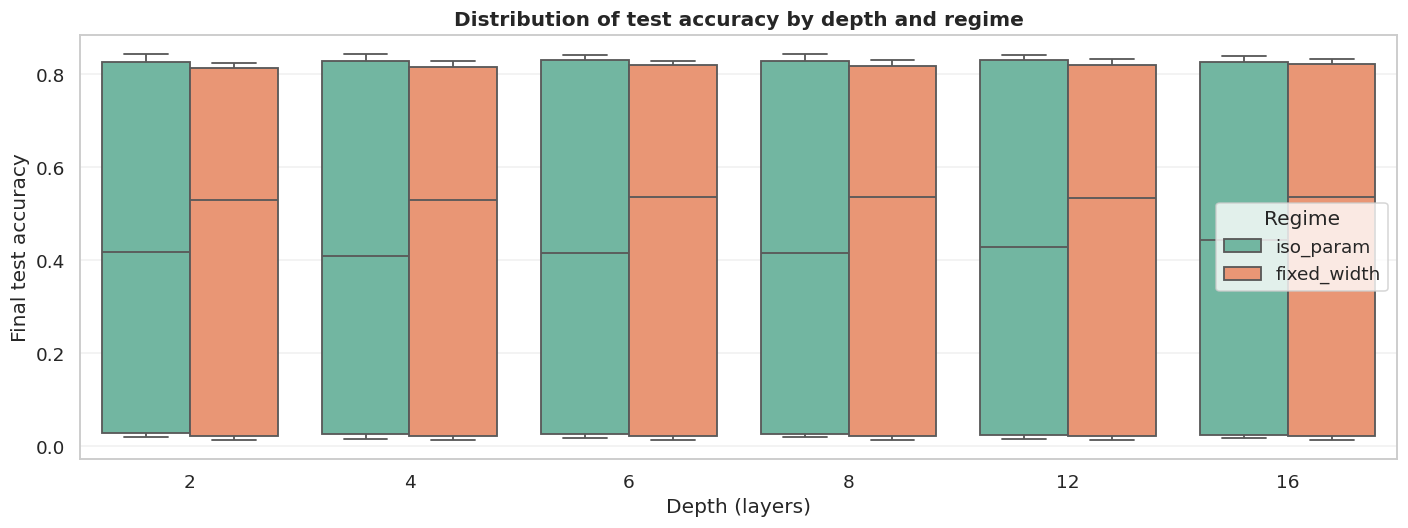

Saved: test_acc_boxplot.png


In [ ]:
# Mean ± std of train and test accuracy by depth (all conditions pooled)
depth_summary = (
    df
    .groupby('depth')[['final_train_acc', 'final_test_acc', 'gen_gap', 'epoch_fraction']]
    .agg(['mean', 'std', 'median'])
    .round(4)
)
print('=== ACCURACY + GEN_GAP + EPOCH_FRACTION BY DEPTH (all conditions pooled) ===')
display(depth_summary)

# Line plot: mean test accuracy vs depth, split by regime
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, regime_name in zip(axes, ['iso_param', 'fixed_width']):
    sub = df[df['regime'] == regime_name]
    for cr in sorted(sub['corruption'].unique()):
        cr_data = sub[sub['corruption'] == cr].groupby('depth')['final_test_acc'].agg(['mean', 'std'])
        ax.plot(cr_data.index, cr_data['mean'], marker='o', label=f'Corruption={cr}')
        ax.fill_between(cr_data.index,
                        cr_data['mean'] - cr_data['std'],
                        cr_data['mean'] + cr_data['std'], alpha=0.12)
    ax.set_title(f'Test accuracy vs depth\n({regime_name})', fontweight='bold')
    ax.set_xlabel('Depth (layers)')
    ax.set_ylabel('Mean test accuracy \u00b1 1 SD')
    ax.set_xticks(sorted(df['depth'].unique()))
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.3)

fig.suptitle('Test accuracy vs depth by corruption rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test_acc_vs_depth.png', dpi=130)
plt.show()
print('Saved: test_acc_vs_depth.png')

# Line plot: mean train accuracy vs depth (the core capacity signal)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, regime_name in zip(axes, ['iso_param', 'fixed_width']):
    sub = df[df['regime'] == regime_name]
    for cr in sorted(sub['corruption'].unique()):
        cr_data = sub[sub['corruption'] == cr].groupby('depth')['final_train_acc'].agg(['mean', 'std'])
        ax.plot(cr_data.index, cr_data['mean'], marker='s', label=f'Corruption={cr}')
        ax.fill_between(cr_data.index,
                        cr_data['mean'] - cr_data['std'],
                        cr_data['mean'] + cr_data['std'], alpha=0.12)
    ax.set_title(f'Train accuracy vs depth\n({regime_name})', fontweight='bold')
    ax.set_xlabel('Depth (layers)')
    ax.set_ylabel('Mean train accuracy \u00b1 1 SD')
    ax.set_xticks(sorted(df['depth'].unique()))
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.3)

fig.suptitle('Train accuracy vs depth by corruption rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('train_acc_vs_depth.png', dpi=130)
plt.show()
print('Saved: train_acc_vs_depth.png')

# Box plots: full distribution of test accuracy per depth x regime
fig, ax = plt.subplots(figsize=(13, 5))
depth_order = sorted(df['depth'].unique())
sns.boxplot(data=df, x='depth', y='final_test_acc', order=depth_order,
            hue='regime', ax=ax, palette='Set2', linewidth=1.2)
ax.set_title('Distribution of test accuracy by depth and regime', fontweight='bold')
ax.set_xlabel('Depth (layers)')
ax.set_ylabel('Final test accuracy')
ax.legend(title='Regime')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('test_acc_boxplot.png', dpi=130)
plt.show()
print('Saved: test_acc_boxplot.png')

---
## 6. Corruption as a capacity probe !!IMPORTANT BOTH
At `corruption=1.0`, the only route to high train accuracy is brute-force memorisation.  
We now use the precomputed `gen_gap` column directly.

=== MEAN GEN_GAP (rows=depth, cols=corruption) ===
  Larger gap at high corruption = higher capacity (model is memorizing noise)
corruption     0.0     0.6     1.0
depth                             
2           0.1643  0.1609  0.5362
4           0.1649  0.1850  0.5601
6           0.1651  0.1887  0.5656
8           0.1648  0.1906  0.5703
12          0.1648  0.1859  0.5729
16          0.1649  0.1676  0.5639


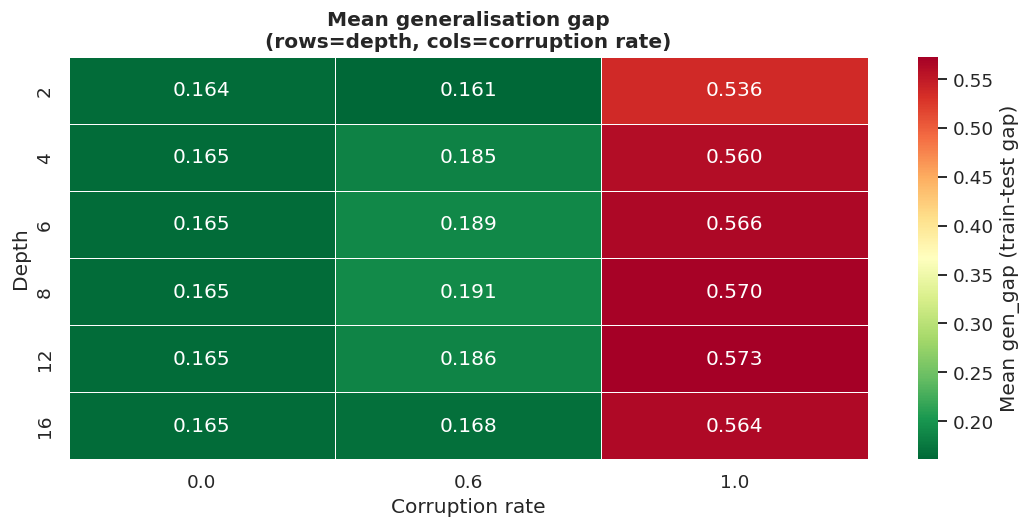

Saved: gen_gap_heatmap.png
=== TRAIN ACCURACY AT CORRUPTION=1.0 (direct memorisation capacity) ===
                     mean     std     min     max
regime      depth                                
fixed_width 2      0.4385  0.0472  0.3553  0.5265
            4      0.4562  0.0545  0.3635  0.5423
            6      0.4657  0.0614  0.3633  0.5749
            8      0.4740  0.0669  0.3707  0.5796
            12     0.4878  0.0680  0.3668  0.5933
            16     0.4964  0.0752  0.3728  0.6231
iso_param   2      0.6788  0.0820  0.5388  0.7991
            4      0.7076  0.0886  0.5536  0.8247
            6      0.7094  0.0885  0.5597  0.8364
            8      0.7096  0.0919  0.5535  0.8448
            12     0.6999  0.0904  0.5495  0.8380
            16     0.6733  0.0977  0.5073  0.8079


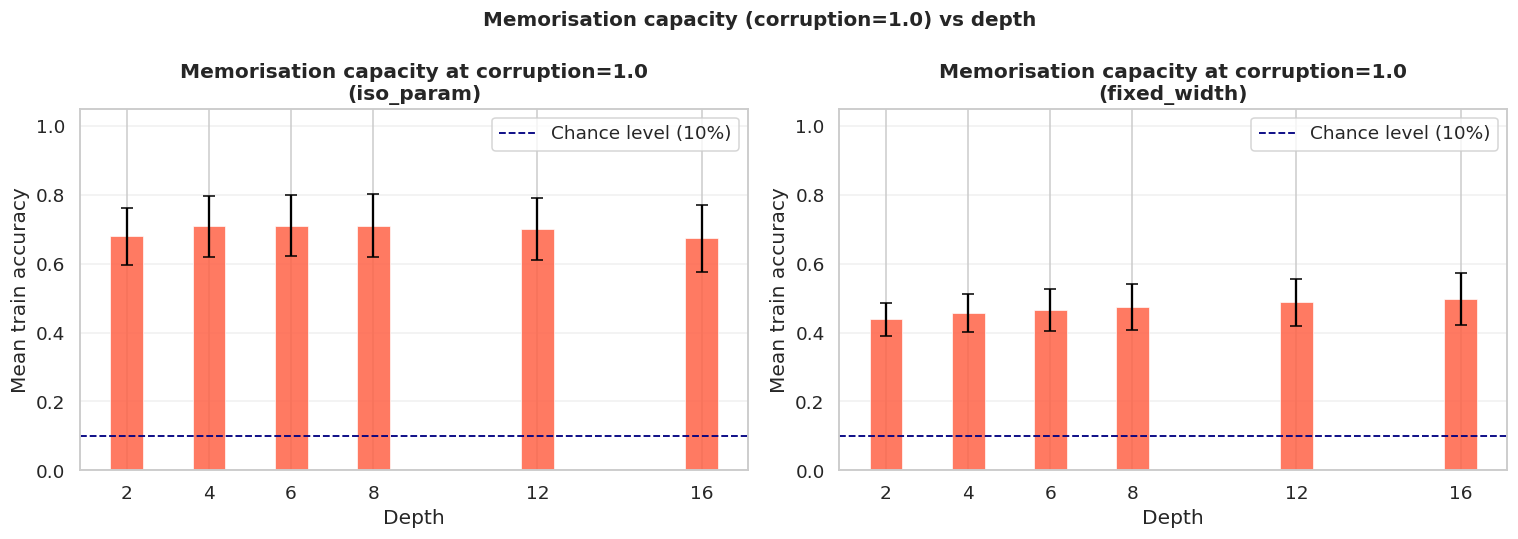

Saved: memorisation_capacity.png
=== SPEARMAN CORRELATION: depth vs train_acc, by corruption level ===
  Positive = deeper helps, Negative = depth penalty

    Corruption         Regime   Spearman r    p-value       Interpretation
  ------------------------------------------------------------------------
           0.0      iso_param      -0.1660     0.0039  depth hurts **
           0.0    fixed_width      +0.2957     0.0000  depth helps **
           0.6      iso_param      -0.0172     0.7662  neutral 
           0.6    fixed_width      +0.3323     0.0000  depth helps **
           1.0      iso_param      -0.0184     0.7514  neutral 
           1.0    fixed_width      +0.2804     0.0000  depth helps **


In [ ]:
# Train-test gap (gen_gap) as a function of depth and corruption
gap_pivot = (
    df
    .groupby(['depth', 'corruption'])['gen_gap']
    .mean()
    .unstack('corruption')
    .round(4)
)
print('=== MEAN GEN_GAP (rows=depth, cols=corruption) ===')
print('  Larger gap at high corruption = higher capacity (model is memorizing noise)')
display(gap_pivot)

# Heatmap of gen_gap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(gap_pivot, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean gen_gap (train-test gap)'})
ax.set_title('Mean generalisation gap\n(rows=depth, cols=corruption rate)', fontweight='bold')
ax.set_xlabel('Corruption rate')
ax.set_ylabel('Depth')
plt.tight_layout()
plt.savefig('gen_gap_heatmap.png', dpi=130)
plt.show()
print('Saved: gen_gap_heatmap.png')

# At corruption=1.0 — direct memorisation capacity measurement
df_noise = df[df['corruption'] == 1.0]

print('=== TRAIN ACCURACY AT CORRUPTION=1.0 (direct memorisation capacity) ===')
noise_summary = (
    df_noise
    .groupby(['regime', 'depth'])['final_train_acc']
    .agg(['mean', 'std', 'min', 'max'])
    .round(4)
)
display(noise_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, regime_name in zip(axes, ['iso_param', 'fixed_width']):
    sub = df_noise[df_noise['regime'] == regime_name]
    depth_means = sub.groupby('depth')['final_train_acc'].agg(['mean', 'std'])
    ax.bar(depth_means.index, depth_means['mean'],
           yerr=depth_means['std'], capsize=4,
           color='tomato', edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axhline(0.1, color='navy', linestyle='--', linewidth=1.2, label='Chance level (10%)')
    ax.set_title(f'Memorisation capacity at corruption=1.0\n({regime_name})', fontweight='bold')
    ax.set_xlabel('Depth')
    ax.set_ylabel('Mean train accuracy')
    ax.set_xticks(sorted(df_noise['depth'].unique()))
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Memorisation capacity (corruption=1.0) vs depth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('memorisation_capacity.png', dpi=130)
plt.show()
print('Saved: memorisation_capacity.png')

# Spearman: depth vs train_acc at each corruption level
print('=== SPEARMAN CORRELATION: depth vs train_acc, by corruption level ===')
print('  Positive = deeper helps, Negative = depth penalty')
print()
print(f'  {"Corruption":>12} {"Regime":>14} {"Spearman r":>12} {"p-value":>10} {"Interpretation":>20}')
print('  ' + '-'*72)

for cr in sorted(df['corruption'].unique()):
    for rg in ['iso_param', 'fixed_width']:
        sub = df[(df['corruption'] == cr) & (df['regime'] == rg)]
        r, p = stats.spearmanr(sub['depth'], sub['final_train_acc'])
        interp = 'depth helps' if r > 0.1 else ('depth hurts' if r < -0.1 else 'neutral')
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        print(f'  {cr:>12.1f} {rg:>14} {r:>+12.4f} {p:>10.4f}  {interp} {sig}')

---
## 7. Regime A vs Regime B comparison !!IMPORTANT
Regime A holds params constant — any depth effect is purely compositional.  
Regime B lets params grow — depth effect = compositional + scale combined.

=== MEAN ACCURACY, GEN_GAP, EPOCH_FRACTION BY REGIME x DEPTH ===
                  final_train_acc         final_test_acc         gen_gap         epoch_fraction     
                             mean     std           mean     std    mean     std           mean  std
regime      depth                                                                                   
fixed_width 2              0.6505  0.2381         0.4561  0.3314  0.1944  0.1778            1.0  0.0
            4              0.6648  0.2333         0.4569  0.3325  0.2079  0.1801            1.0  0.0
            6              0.6716  0.2304         0.4594  0.3335  0.2122  0.1847            1.0  0.0
            8              0.6775  0.2278         0.4596  0.3341  0.2178  0.1870            1.0  0.0
            12             0.6856  0.2230         0.4603  0.3345  0.2253  0.1908            1.0  0.0
            16             0.6913  0.2205         0.4610  0.3354  0.2303  0.1952            1.0  0.0
iso_param   2             

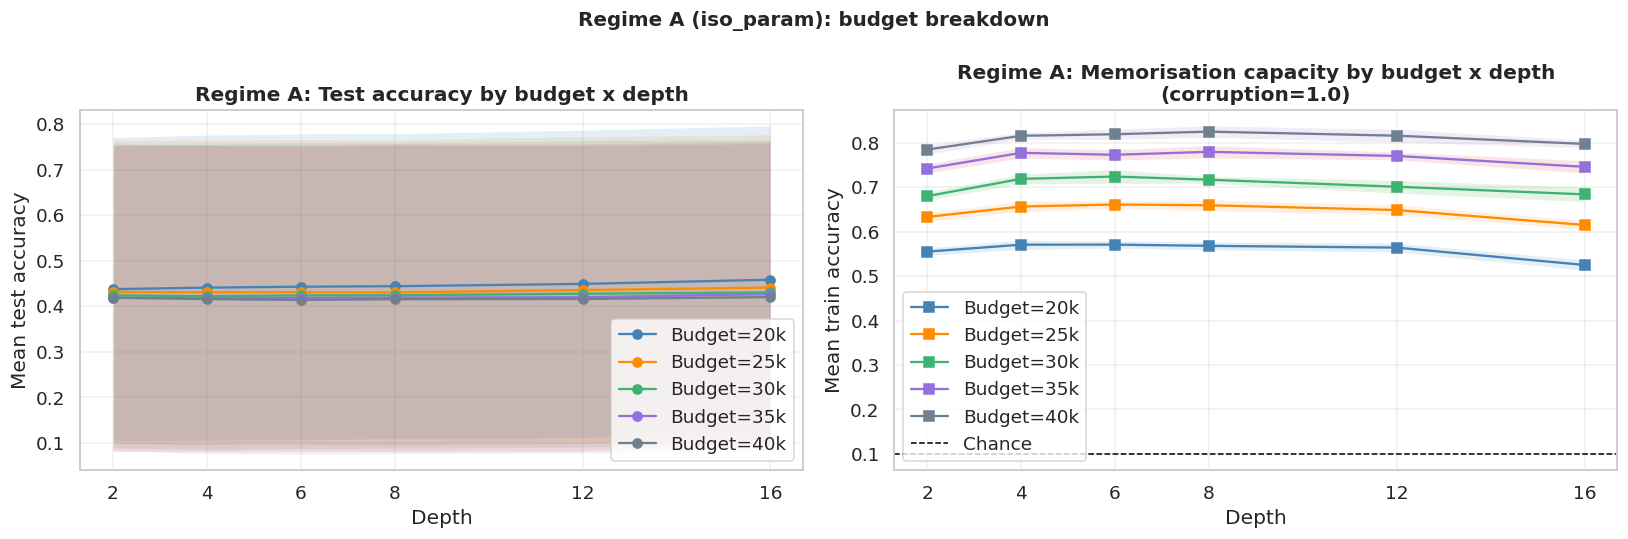

Saved: regime_a_budget_breakdown.png


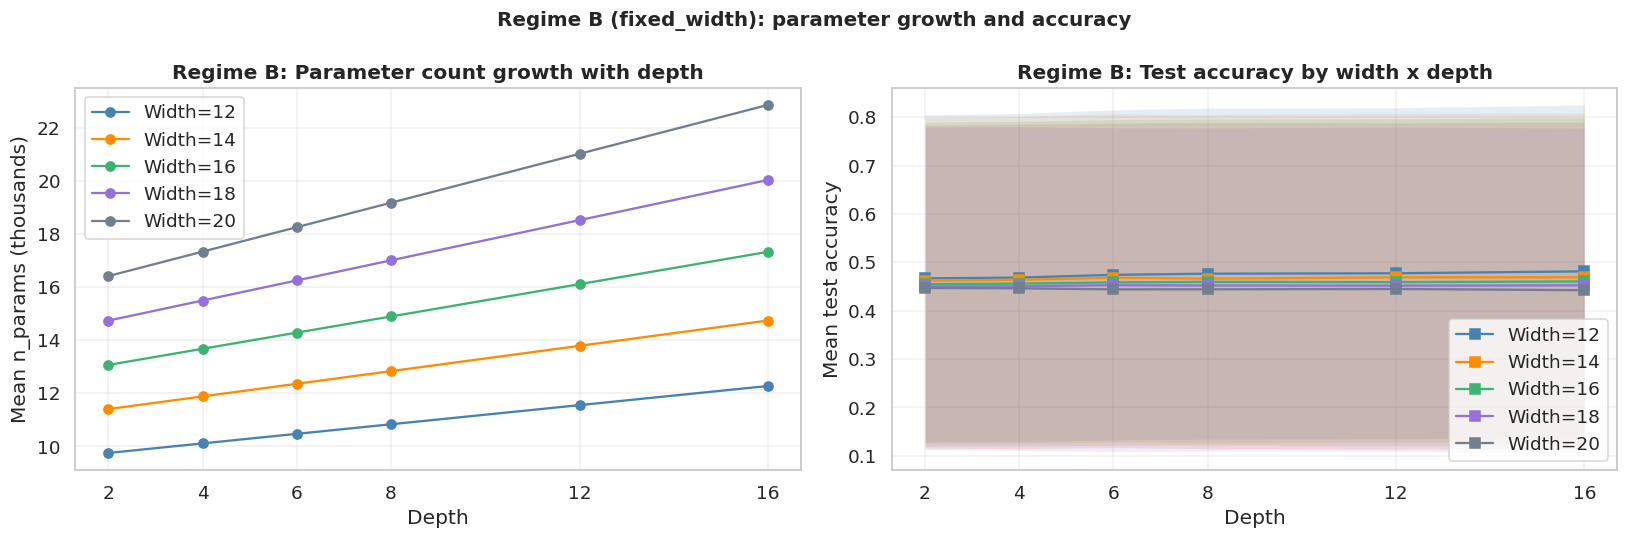

Saved: regime_b_params_and_acc.png


In [ ]:
# Summary by regime x depth
regime_summary = (
    df
    .groupby(['regime', 'depth'])[['final_train_acc', 'final_test_acc', 'gen_gap', 'epoch_fraction']]
    .agg(['mean', 'std'])
    .round(4)
)
print('=== MEAN ACCURACY, GEN_GAP, EPOCH_FRACTION BY REGIME x DEPTH ===')
display(regime_summary)

# Regime A: compare budgets within the same depth
df_a = df[df['regime'] == 'iso_param'].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
budget_colors = {
    20000: 'steelblue',
    25000: 'darkorange',
    30000: 'mediumseagreen',
    35000: 'mediumpurple',
    40000: 'slategray'
}

# Test acc by budget and depth
ax = axes[0]
for budget in sorted(df_a['budget'].unique()):
    sub = df_a[df_a['budget'] == budget].groupby('depth')['final_test_acc'].agg(['mean', 'std'])
    ax.plot(sub.index, sub['mean'], marker='o',
            color=budget_colors[int(budget)], label=f'Budget={int(budget/1000)}k')
    ax.fill_between(sub.index, sub['mean'] - sub['std'], sub['mean'] + sub['std'], alpha=0.12)
ax.set_title('Regime A: Test accuracy by budget x depth', fontweight='bold')
ax.set_xlabel('Depth'); ax.set_ylabel('Mean test accuracy')
ax.set_xticks(sorted(df_a['depth'].unique())); ax.legend(); ax.grid(True, alpha=0.3)

# Memorisation (corruption=1.0) by budget and depth — the key capacity breakpoint chart
ax = axes[1]
df_a_noise = df_a[df_a['corruption'] == 1.0]
for budget in sorted(df_a['budget'].unique()):
    sub = df_a_noise[df_a_noise['budget'] == budget].groupby('depth')['final_train_acc'].agg(['mean', 'std'])
    ax.plot(sub.index, sub['mean'], marker='s',
            color=budget_colors[int(budget)], label=f'Budget={int(budget/1000)}k')
    ax.fill_between(sub.index, sub['mean'] - sub['std'], sub['mean'] + sub['std'], alpha=0.12)
ax.axhline(0.1, color='black', linestyle='--', linewidth=1, label='Chance')
ax.set_title('Regime A: Memorisation capacity by budget x depth\n(corruption=1.0)', fontweight='bold')
ax.set_xlabel('Depth'); ax.set_ylabel('Mean train accuracy')
ax.set_xticks(sorted(df_a['depth'].unique())); ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle('Regime A (iso_param): budget breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regime_a_budget_breakdown.png', dpi=130)
plt.show()
print('Saved: regime_a_budget_breakdown.png')

# Regime B: parameter growth and test accuracy
df_b = df[df['regime'] == 'fixed_width'].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
width_colors = {12: 'steelblue', 14: 'darkorange', 16: 'mediumseagreen', 18: 'mediumpurple', 20: 'slategray'}

# Parameter growth
ax = axes[0]
for fw in sorted(df_b['fixed_w'].unique()):
    sub = df_b[df_b['fixed_w'] == fw].groupby('depth')['n_params'].mean()
    ax.plot(sub.index, sub.values / 1000, marker='o',
            color=width_colors[int(fw)], label=f'Width={int(fw)}')
ax.set_title('Regime B: Parameter count growth with depth', fontweight='bold')
ax.set_xlabel('Depth'); ax.set_ylabel('Mean n_params (thousands)')
ax.set_xticks(sorted(df_b['depth'].unique())); ax.legend(); ax.grid(True, alpha=0.3)

# Test accuracy by width and depth
ax = axes[1]
for fw in sorted(df_b['fixed_w'].unique()):
    sub = df_b[df_b['fixed_w'] == fw].groupby('depth')['final_test_acc'].agg(['mean', 'std'])
    ax.plot(sub.index, sub['mean'], marker='s',
            color=width_colors[int(fw)], label=f'Width={int(fw)}')
    ax.fill_between(sub.index, sub['mean'] - sub['std'], sub['mean'] + sub['std'], alpha=0.12)
ax.set_title('Regime B: Test accuracy by width x depth', fontweight='bold')
ax.set_xlabel('Depth'); ax.set_ylabel('Mean test accuracy')
ax.set_xticks(sorted(df_b['depth'].unique())); ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle('Regime B (fixed_width): parameter growth and accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regime_b_params_and_acc.png', dpi=130)
plt.show()
print('Saved: regime_b_params_and_acc.png')

---
## 8. Loss trajectory analysis
Using `loss_ep10`, `loss_ep20`, `loss_ep30`, `loss_ep50`, `loss_ep70`, and `loss_ep90` plus `loss_drop_10_to_final`.

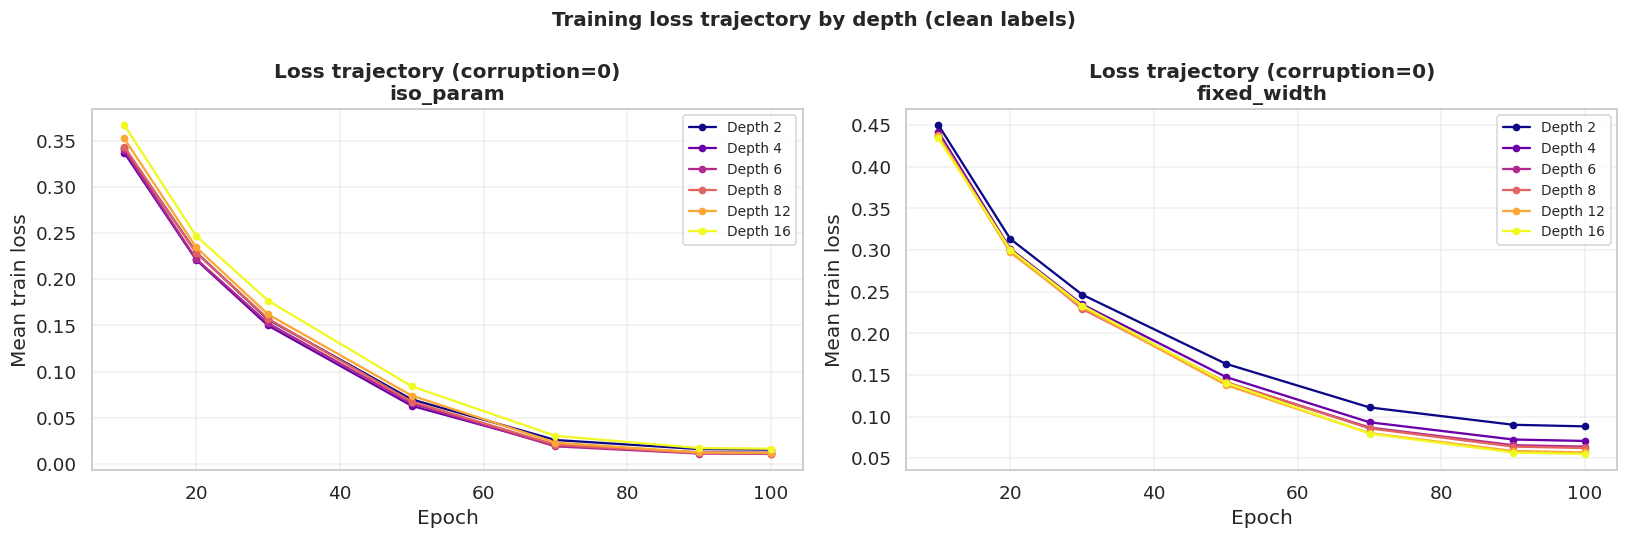

Saved: loss_trajectory_clean.png


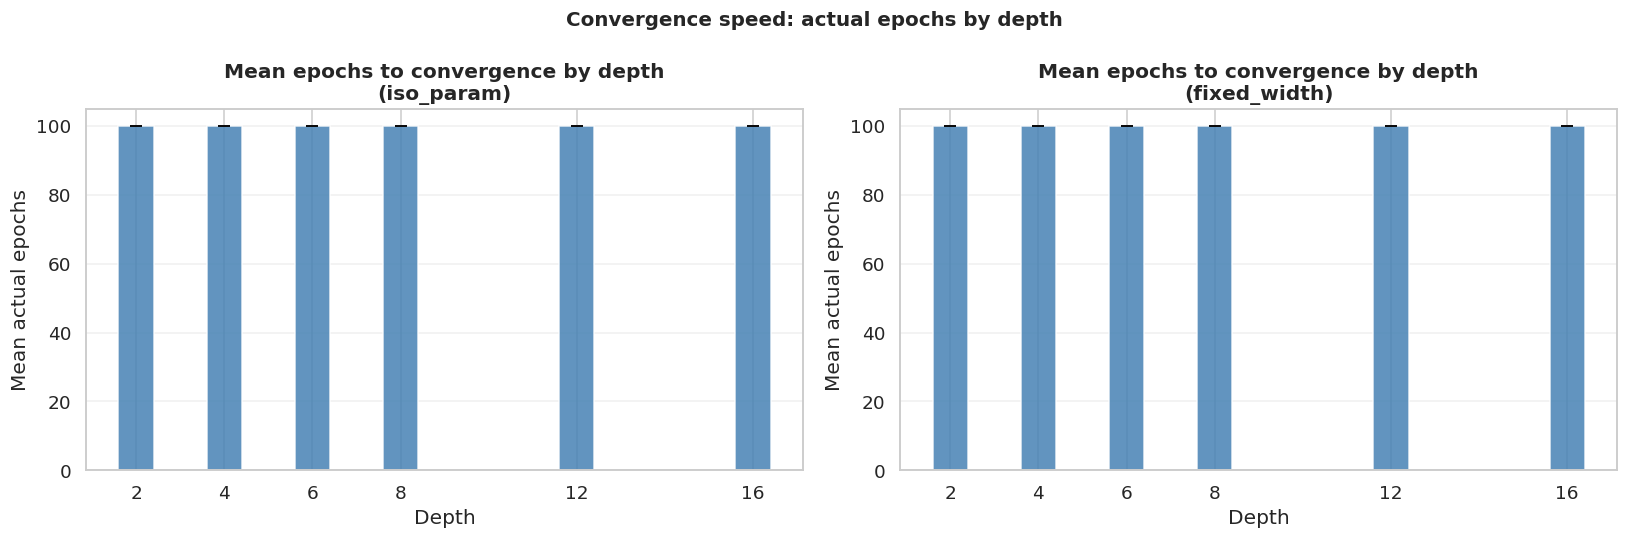

Saved: convergence_epochs.png
=== LOSS DROP (ep10 -> final) BY DEPTH AND REGIME ===
                     mean     std  median
regime      depth                        
fixed_width 2      0.5050  0.1315  0.4917
            4      0.5436  0.1561  0.5364
            6      0.5636  0.1733  0.5427
            8      0.5812  0.1873  0.5652
            12     0.6068  0.2037  0.5975
            16     0.6222  0.2227  0.5946
iso_param   2      0.8684  0.4191  0.9897
            4      0.9245  0.4637  1.0523
            6      0.9393  0.4722  1.0693
            8      0.9427  0.4760  1.0666
            12     0.9351  0.4635  1.0552
            16     0.8966  0.4363  0.9865


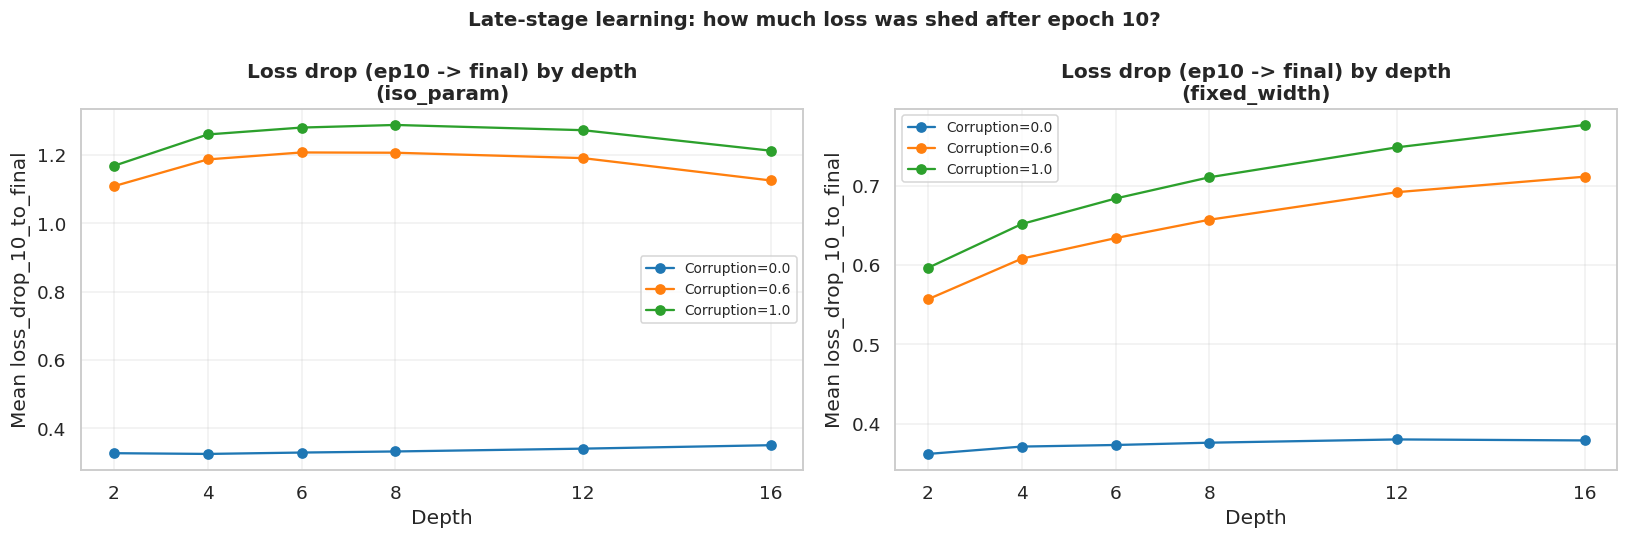

Saved: loss_drop_10_to_final.png


In [ ]:
# Average loss trajectory by depth at clean labels (corruption=0)
df_clean = df[df['corruption'] == 0.0].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
depths = sorted(df_clean['depth'].unique())
cmap = plt.cm.get_cmap('plasma', len(depths))

for ax, regime_name in zip(axes, ['iso_param', 'fixed_width']):
    sub = df_clean[df_clean['regime'] == regime_name]
    for i, depth in enumerate(depths):
        d_sub = sub[sub['depth'] == depth]
        xs = [10, 20, 30, 50, 70, 90]
        ys = [d_sub[f'loss_ep{ep}'].mean() for ep in xs]
        xs.append(int(d_sub['actual_epochs'].mean()))
        ys.append(d_sub['final_train_loss'].mean())
        ax.plot(xs, ys, marker='o', markersize=4, color=cmap(i), label=f'Depth {depth}')
    ax.set_title(f'Loss trajectory (corruption=0)\n{regime_name}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean train loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Training loss trajectory by depth (clean labels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_trajectory_clean.png', dpi=130)
plt.show()
print('Saved: loss_trajectory_clean.png')

# Epochs to convergence: epoch_fraction (new) and actual_epochs by depth
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, regime_name in zip(axes, ['iso_param', 'fixed_width']):
    sub = df[df['regime'] == regime_name]
    epoch_by_depth = sub.groupby('depth')['actual_epochs'].agg(['mean', 'std'])
    ax.bar(epoch_by_depth.index, epoch_by_depth['mean'],
           yerr=epoch_by_depth['std'], capsize=4,
           color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'Mean epochs to convergence by depth\n({regime_name})', fontweight='bold')
    ax.set_xlabel('Depth')
    ax.set_ylabel('Mean actual epochs')
    ax.set_xticks(sorted(sub['depth'].unique()))
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Convergence speed: actual epochs by depth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('convergence_epochs.png', dpi=130)
plt.show()
print('Saved: convergence_epochs.png')

# loss_drop_10_to_final: how much did the model keep improving after epoch 10?
# Larger drop = model was still learning a lot after ep10 = slower starter
print('=== LOSS DROP (ep10 -> final) BY DEPTH AND REGIME ===')
loss_drop_summary = (
    df
    .groupby(['regime', 'depth'])['loss_drop_10_to_final']
    .agg(['mean', 'std', 'median'])
    .round(4)
)
display(loss_drop_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, regime_name in zip(axes, ['iso_param', 'fixed_width']):
    sub = df[df['regime'] == regime_name]
    for cr in sorted(sub['corruption'].unique()):
        cr_data = sub[sub['corruption'] == cr].groupby('depth')['loss_drop_10_to_final'].agg(['mean', 'std'])
        ax.plot(cr_data.index, cr_data['mean'], marker='o', label=f'Corruption={cr}')
    ax.set_title(f'Loss drop (ep10 -> final) by depth\n({regime_name})', fontweight='bold')
    ax.set_xlabel('Depth'); ax.set_ylabel('Mean loss_drop_10_to_final')
    ax.set_xticks(sorted(df['depth'].unique()))
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('Late-stage learning: how much loss was shed after epoch 10?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_drop_10_to_final.png', dpi=130)
plt.show()
print('Saved: loss_drop_10_to_final.png')

---
## 9. Engineered features — new diagnostics YELLOW ONE + COLORS NEED

These columns exist only in the preprocessed dataset and provide additional analytical angles.

=== DEPTH_PER_PARAM BY REGIME x DEPTH ===
                       mean       std
regime      depth                    
fixed_width 2      0.000158  0.000030
            4      0.000303  0.000059
            6      0.000435  0.000087
            8      0.000557  0.000114
            12     0.000775  0.000166
            16     0.000962  0.000215
iso_param   2      0.000072  0.000018
            4      0.000144  0.000038
            6      0.000217  0.000057
            8      0.000288  0.000077
            12     0.000430  0.000108
            16     0.000592  0.000157


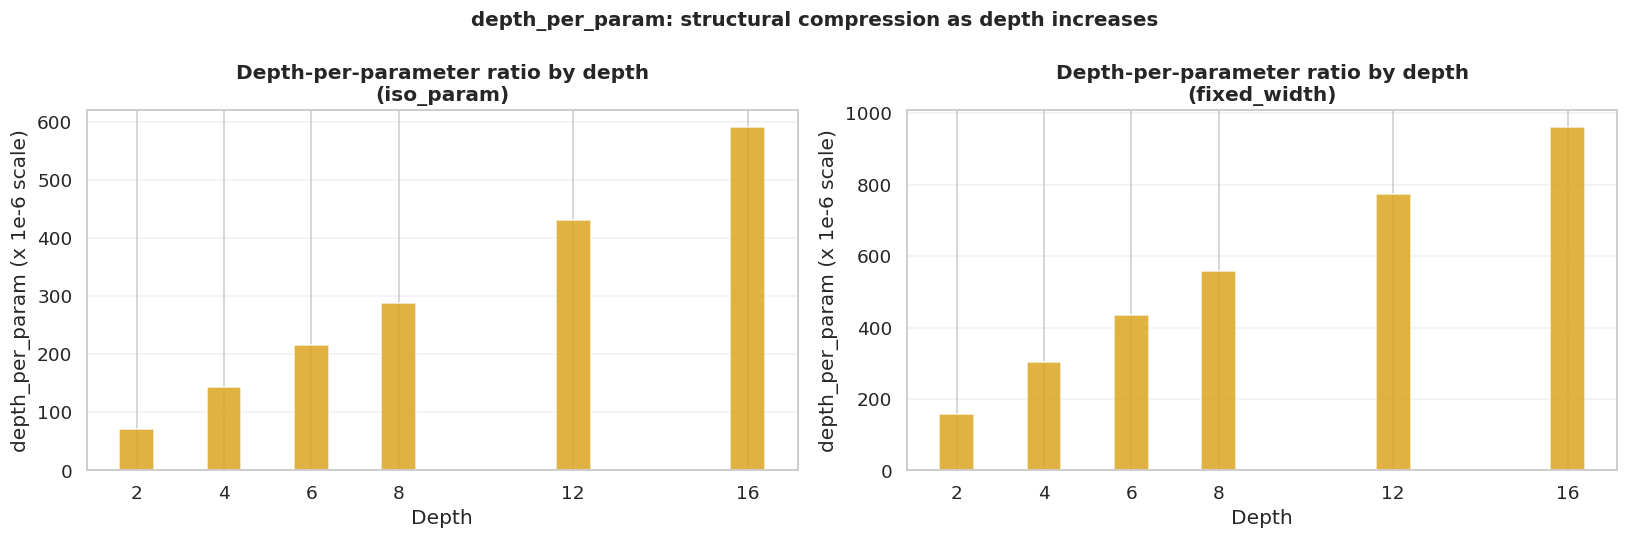

Saved: depth_per_param.png
=== EPOCH_FRACTION BY DEPTH AND CORRUPTION ===
corruption  0.0  0.6  1.0
depth                    
2           1.0  1.0  1.0
4           1.0  1.0  1.0
6           1.0  1.0  1.0
8           1.0  1.0  1.0
12          1.0  1.0  1.0
16          1.0  1.0  1.0


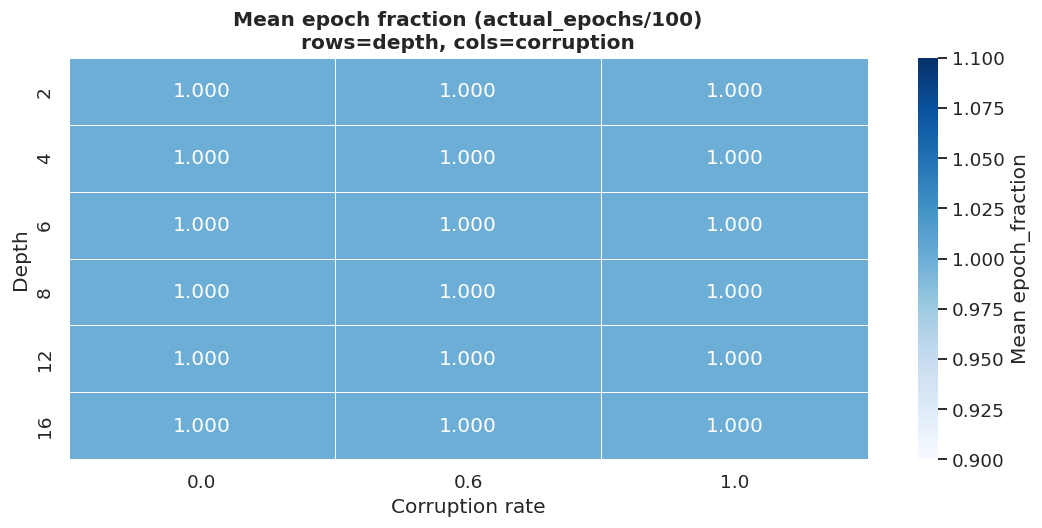

Saved: epoch_fraction_heatmap.png


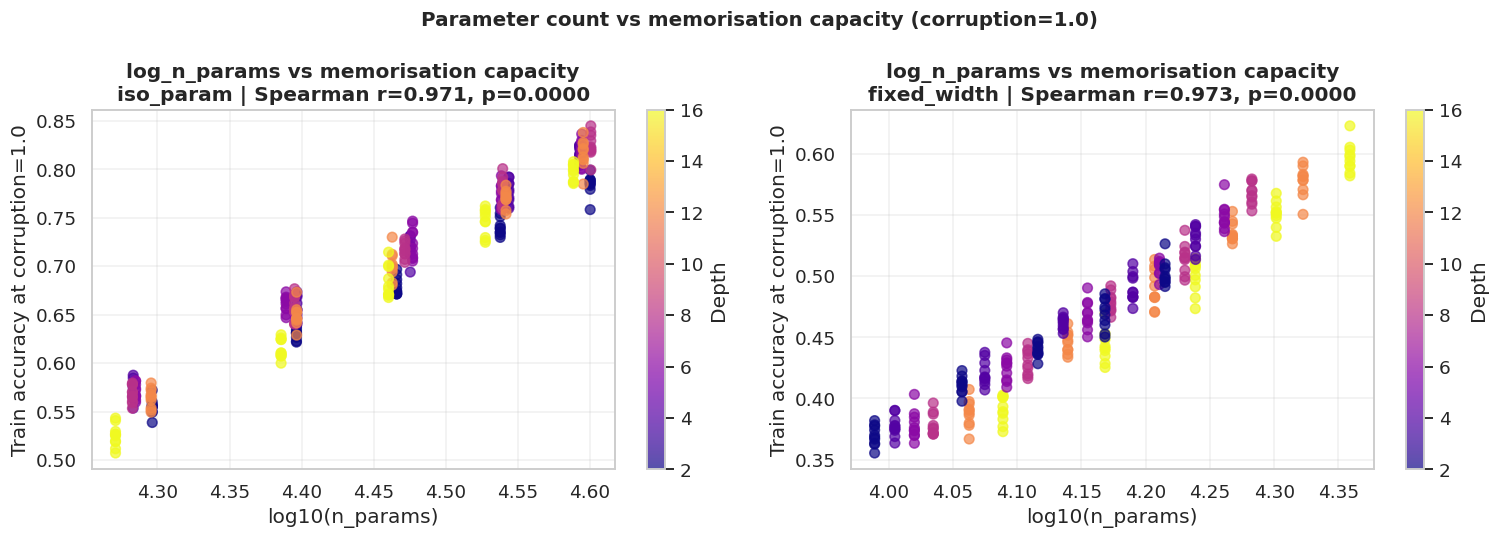

Saved: log_params_vs_memorisation.png


In [ ]:
# depth_per_param: the key iso_param confound expressed as a ratio
# As depth increases in iso_param, depth_per_param rises (more layers competing for fewer params each)
print('=== DEPTH_PER_PARAM BY REGIME x DEPTH ===')
dpp_summary = (
    df
    .groupby(['regime', 'depth'])['depth_per_param']
    .agg(['mean', 'std'])
    .round(8)
)
display(dpp_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, regime_name in zip(axes, ['iso_param', 'fixed_width']):
    sub = df[df['regime'] == regime_name]
    dpp = sub.groupby('depth')['depth_per_param'].mean()
    ax.bar(dpp.index, dpp.values * 1e6, color='goldenrod', edgecolor='white', alpha=0.85)
    ax.set_title(f'Depth-per-parameter ratio by depth\n({regime_name})', fontweight='bold')
    ax.set_xlabel('Depth'); ax.set_ylabel('depth_per_param (x 1e-6 scale)')
    ax.set_xticks(sorted(sub['depth'].unique()))
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('depth_per_param: structural compression as depth increases',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('depth_per_param.png', dpi=130)
plt.show()
print('Saved: depth_per_param.png')

# epoch_fraction: how much of the 100-epoch budget was used?
# Near 1.0 = ran to max epochs (harder task / slower model)
print('=== EPOCH_FRACTION BY DEPTH AND CORRUPTION ===')
ef_summary = (
    df
    .groupby(['depth', 'corruption'])['epoch_fraction']
    .mean()
    .unstack('corruption')
    .round(3)
)
display(ef_summary)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ef_summary, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean epoch_fraction'})
ax.set_title('Mean epoch fraction (actual_epochs/100)\nrows=depth, cols=corruption',
             fontweight='bold')
ax.set_xlabel('Corruption rate')
ax.set_ylabel('Depth')
plt.tight_layout()
plt.savefig('epoch_fraction_heatmap.png', dpi=130)
plt.show()
print('Saved: epoch_fraction_heatmap.png')

# log_n_params vs memorisation capacity — visualise the parameter confounder
df_noise = df[df['corruption'] == 1.0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, regime_name in zip(axes, ['iso_param', 'fixed_width']):
    sub = df_noise[df_noise['regime'] == regime_name]
    sc = ax.scatter(sub['log_n_params'], sub['final_train_acc'],
                    c=sub['depth'], cmap='plasma', alpha=0.7, s=40)
    plt.colorbar(sc, ax=ax, label='Depth')
    r, p = stats.spearmanr(sub['log_n_params'], sub['final_train_acc'])
    ax.set_title(f'log_n_params vs memorisation capacity\n{regime_name} | Spearman r={r:.3f}, p={p:.4f}',
                 fontweight='bold')
    ax.set_xlabel('log10(n_params)')
    ax.set_ylabel('Train accuracy at corruption=1.0')
    ax.grid(True, alpha=0.3)

fig.suptitle('Parameter count vs memorisation capacity (corruption=1.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('log_params_vs_memorisation.png', dpi=130)
plt.show()
print('Saved: log_params_vs_memorisation.png')

---
## 10. Optimization failure audit

In [ ]:
n_failures = df['optimization_failure'].astype(bool).sum()
print('=== OPTIMIZATION FAILURE AUDIT ===')
print(f'  Total flagged failures: {n_failures} / {len(df)} ({100*n_failures/len(df):.1f}%)')

if n_failures > 0:
    fail_by_depth = df.groupby('depth')['optimization_failure'].agg(['sum', 'mean'])
    fail_by_depth.columns = ['n_failures', 'failure_rate']
    print('\n  Failures by depth:')
    display(fail_by_depth)
else:
    print('\n  No failures flagged — all runs converged above threshold.')

# Near-boundary check: train_acc 10-20%
near_boundary = df[(df['final_train_acc'] > 0.10) & (df['final_train_acc'] < 0.20)]
print(f'\n=== NEAR-BOUNDARY RUNS (10% < train_acc < 20%) ===')
print(f'  Count: {len(near_boundary)}')
if len(near_boundary) > 0:
    print('  Distribution by depth and corruption:')
    display(near_boundary.groupby(['depth', 'corruption']).size().rename('n_near_boundary'))

=== OPTIMIZATION FAILURE AUDIT ===
  Total flagged failures: 0 / 1800 (0.0%)

  No failures flagged — all runs converged above threshold.

=== NEAR-BOUNDARY RUNS (10% < train_acc < 20%) ===
  Count: 0


---
## 11. Summary table & correlation matrix

=== MASTER SUMMARY TABLE ===
         regime  depth  corruption   n  mean_train_acc  std_train_acc  mean_test_acc  std_test_acc  mean_gen_gap  mean_epoch_frac  mean_loss_drop  mean_epochs  mean_final_loss
0   fixed_width      2         0.0  50          0.9779         0.0106         0.8169        0.0042        0.1609              1.0          0.3619        100.0           0.0882
1   fixed_width      2         0.6  50          0.5350         0.0360         0.5318        0.0286        0.0033              1.0          0.5568        100.0           1.4647
2   fixed_width      2         1.0  50          0.4385         0.0472         0.0195        0.0027        0.4190              1.0          0.5964        100.0           1.6218
3   fixed_width      4         0.0  50          0.9837         0.0094         0.8197        0.0041        0.1640              1.0          0.3712        100.0           0.0707
4   fixed_width      4         0.6  50          0.5544         0.0435         0.5316       

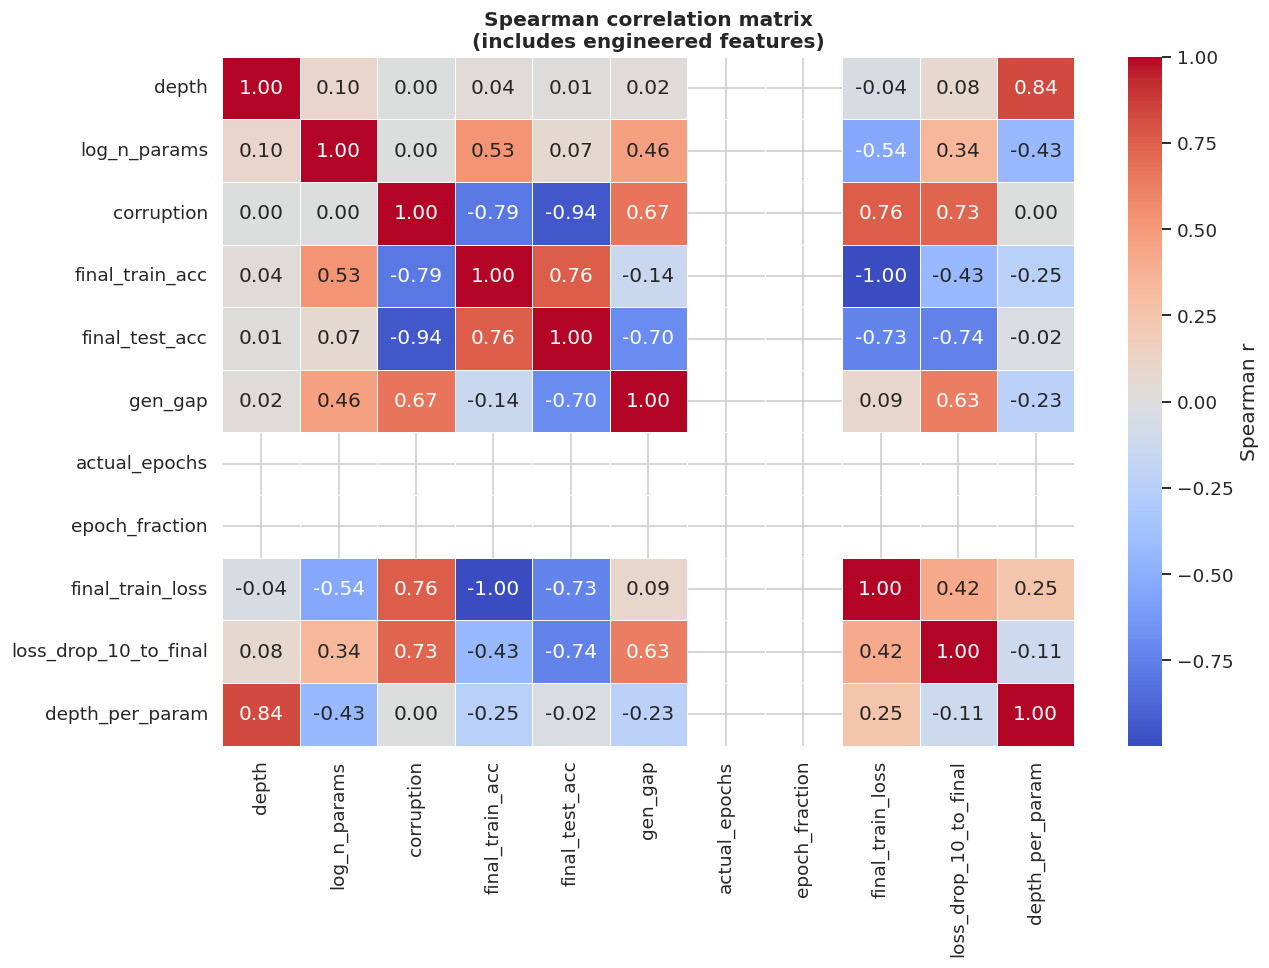

Saved: correlation_matrix_extended.png
DATASET SUITABILITY CHECKLIST (Preprocessed version)

[1] Sample size: 1800 runs
    Runs per depth group: 300–300

[2] Depth groups balanced: YES

[3] Median within-cell std (test acc): 0.0042

[4] Optimization failure rate: 0.0%
    Acceptable

[5] Corruption levels: [np.float64(0.0), np.float64(0.6), np.float64(1.0)]
    Includes corruption=1.0: True

[6] Regimes present: ['iso_param', 'fixed_width']

[7] Loss snapshot null rate (loss_ep10): 0.0%

[8] New engineered columns available: 9 columns
    Includes: gen_gap, epoch_fraction, log_n_params, depth_per_param,
    loss_drop_10_to_final, total_flops

Ready for inferential analysis: all checks pass.


In [ ]:
# Master summary table — now includes gen_gap and epoch_fraction
summary_table = (
    df
    .groupby(['regime', 'depth', 'corruption'])
    .agg(
        n                 = ('seed', 'count'),
        mean_train_acc    = ('final_train_acc',       'mean'),
        std_train_acc     = ('final_train_acc',       'std'),
        mean_test_acc     = ('final_test_acc',        'mean'),
        std_test_acc      = ('final_test_acc',        'std'),
        mean_gen_gap      = ('gen_gap',               'mean'),
        mean_epoch_frac   = ('epoch_fraction',        'mean'),
        mean_loss_drop    = ('loss_drop_10_to_final', 'mean'),
        mean_epochs       = ('actual_epochs',         'mean'),
        mean_final_loss   = ('final_train_loss',      'mean'),
    )
    .round(4)
    .reset_index()
)

print('=== MASTER SUMMARY TABLE ===')
display(summary_table)

summary_table.to_csv('descriptive_summary_table_preprocessed.csv', index=False)
print('\nSaved: descriptive_summary_table_preprocessed.csv')

# Extended Spearman correlation matrix — includes engineered features
corr_cols = [
    'depth', 'log_n_params', 'corruption',
    'final_train_acc', 'final_test_acc', 'gen_gap',
    'actual_epochs', 'epoch_fraction', 'final_train_loss',
    'loss_drop_10_to_final', 'depth_per_param'
]
corr_matrix = df[corr_cols].corr(method='spearman').round(3)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Spearman r'})
ax.set_title('Spearman correlation matrix\n(includes engineered features)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix_extended.png', dpi=130)
plt.show()
print('Saved: correlation_matrix_extended.png')

# Final readiness verdict
print('=' * 65)
print('DATASET SUITABILITY CHECKLIST (Preprocessed version)')
print('=' * 65)

print(f'\n[1] Sample size: {len(df)} runs')
print(f'    Runs per depth group: {df.groupby("depth").size().min()}–{df.groupby("depth").size().max()}')

depth_counts = df.groupby('depth').size()
balanced = depth_counts.max() - depth_counts.min() <= 5
print(f'\n[2] Depth groups balanced: {"YES" if balanced else "NO"}')

cell_var_check = (
    df.groupby(['regime', 'depth', 'corruption'])['final_test_acc'].std().median()
)
print(f'\n[3] Median within-cell std (test acc): {cell_var_check:.4f}')
print(f'    {"Sufficient variance" if cell_var_check > 0.005 else "WARNING: low variance"}')

fail_rate = df['optimization_failure'].astype(bool).mean()
print(f'\n[4] Optimization failure rate: {fail_rate:.1%}')
print(f'    {"Acceptable" if fail_rate < 0.05 else "HIGH"}')

print(f'\n[5] Corruption levels: {sorted(df["corruption"].unique())}')
print(f'    Includes corruption=1.0: {1.0 in df["corruption"].values}')

print(f'\n[6] Regimes present: {list(df["regime"].unique())}')

snap_null_rate = df['loss_ep10'].isnull().mean()
print(f'\n[7] Loss snapshot null rate (loss_ep10): {snap_null_rate:.1%}')

print(f'\n[8] New engineered columns available: {len([c for c in df.columns if c not in original_cols])} columns')
print(f'    Includes: gen_gap, epoch_fraction, log_n_params, depth_per_param,')
print(f'    loss_drop_10_to_final, total_flops')

print()
print('Ready for inferential analysis: all checks pass.')